# 03 &mdash; Stationarity Diagnostics

Before fitting any model, this notebook asks a blunt question:
*how forecastable is this series, in theory?* It runs the standard
finance-econometrics battery for characterizing weak-form market
efficiency &mdash; stationarity (ADF / KPSS / Phillips-Perron), return
autocorrelation (Ljung-Box), and the Lo-MacKinlay variance ratio. All
three converge on the same answer: coffee futures behave as a
near-random walk.

## Why this notebook exists

If the series had exploitable structure, we'd expect complex models to
beat naive baselines. The a priori metrics let us form an expectation
*before* seeing any forecast results &mdash; which is methodologically
important, because it turns the benchmark from "a fishing expedition"
into a hypothesis test of whether any model can extract what the
diagnostics say isn't there.

A companion notebook, [`03b_exploratory_dynamics.ipynb`](03b_exploratory_dynamics.ipynb),
runs additional diagnostics drawn from the nonlinear-dynamics and
signal-processing literatures (Hurst + Lo's R/S, spectral
predictability, permutation entropy, Rosenstein Lyapunov with a
surrogate-data null). Those metrics independently confirm the
near-random-walk verdict but are not load-bearing for it &mdash; the
standard battery in this notebook already settles the question.

## 1. Setup

In [1]:
import sys
from pathlib import Path

# Make `coffee_forecast` importable whether or not `pip install -e .`
# is in effect for this kernel. No-op when the package is already on
# sys.path (e.g. via the editable install); falls back to inserting
# the repo root so the notebook also runs from a fresh clone.
try:
    import coffee_forecast  # noqa: F401
except ModuleNotFoundError:
    sys.path.insert(0, str(Path.cwd().parent))

import matplotlib.pyplot as plt
import numpy as np

from coffee_forecast import load_coffee_data
from coffee_forecast.config import FIG_DIR

FIG_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
df = load_coffee_data()
prices = df["y"].values.astype(float)
log_returns = np.diff(np.log(prices))

print(
    f"Loaded {len(df)} trading days ({df['ds'].min().date()} → {df['ds'].max().date()})"
)
print(
    f"  prices:      {len(prices)} observations, "
    f"min={prices.min():.1f}, max={prices.max():.1f}"
)
print(
    f"  log-returns: {len(log_returns)} observations, "
    f"mean={log_returns.mean():+.5f}, std={log_returns.std():.4f}"
)

Loaded 8104 trading days (1994-01-03 → 2026-01-30)
  prices:      8104 observations, min=41.5, max=438.9
  log-returns: 8103 observations, mean=+0.00019, std=0.0237


## 2. Stationarity: prices vs. log-returns

Before any of the diagnostics that follow, we need to know which
representation each test should run on. Several diagnostics
(variance ratio, Hurst + R/S, the Lyapunov surrogate's
reconstruction) are defined only for stationary series and so use
log-returns; others (spectral $\Omega$, permutation entropy) we run
on both representations to expose the contrast. We start by
verifying the stationarity status of each with an Augmented
Dickey-Fuller test.

In [3]:
from statsmodels.tsa.stattools import adfuller

adf_price = adfuller(prices, autolag="AIC")
adf_ret = adfuller(log_returns, autolag="AIC")

print("Augmented Dickey-Fuller Test:")
print(
    f"  Prices      : ADF = {adf_price[0]:+7.3f},  p = {adf_price[1]:6.3f}  "
    f"→ {'Non-stationary' if adf_price[1] > 0.05 else 'Stationary'}"
)
print(
    f"  Log-returns : ADF = {adf_ret[0]:+7.3f},  p = {adf_ret[1]:.2e}  "
    f"→ {'Non-stationary' if adf_ret[1] > 0.05 else 'Stationary'}"
)

Augmented Dickey-Fuller Test:
  Prices      : ADF =  -1.451,  p =  0.557  → Non-stationary
  Log-returns : ADF = -20.879,  p = 0.00e+00  → Stationary


### 2b. Confirmatory unit-root tests: KPSS and Phillips-Perron

ADF is the standard first-pass test but has known weaknesses: low power
against persistent stationary alternatives, and it assumes homoskedastic
errors (which §4 of notebook 04 will show coffee returns violate). Two
complementary tests sharpen the conclusion:

- **KPSS** (Kwiatkowski et al. 1992) *reverses* the null: H0 is
  stationarity, rejection means non-stationarity. Pairing it with ADF
  creates a confirmatory design &mdash; agreement across both tests is
  stronger evidence than either alone.
- **Phillips-Perron** (1988) has the same null as ADF but uses a
  non-parametric correction for heteroskedasticity and serial
  correlation in the errors. Robust to the volatility clustering in
  coffee returns.

In [4]:
from statsmodels.tsa.stattools import kpss
from arch.unitroot import PhillipsPerron

# KPSS on prices (H0: stationary)
kpss_price_stat, kpss_price_p, kpss_price_lag, kpss_price_crit = kpss(
    prices, regression="c", nlags="auto"
)
# KPSS on log-returns
kpss_ret_stat, kpss_ret_p, kpss_ret_lag, kpss_ret_crit = kpss(
    log_returns, regression="c", nlags="auto"
)

# Phillips-Perron on prices (H0: unit root, same direction as ADF)
pp_price = PhillipsPerron(prices)
pp_ret = PhillipsPerron(log_returns)

print("KPSS Test  (H0: stationary  \u2192  reject means NON-stationary)")
print(
    f"  Prices      : stat = {kpss_price_stat:+7.3f},  p = {kpss_price_p:.3f}  "
    f"\u2192 {'Reject (non-stationary)' if kpss_price_p < 0.05 else 'Fail to reject (stationary)'}"
)
print(
    f"  Log-returns : stat = {kpss_ret_stat:+7.3f},  p = {kpss_ret_p:.3f}  "
    f"\u2192 {'Reject (non-stationary)' if kpss_ret_p < 0.05 else 'Fail to reject (stationary)'}"
)
print()
print("Phillips-Perron Test  (H0: unit root  \u2192  reject means stationary)")
print(
    f"  Prices      : stat = {pp_price.stat:+7.3f},  p = {pp_price.pvalue:.3f}  "
    f"\u2192 {'Stationary' if pp_price.pvalue < 0.05 else 'Non-stationary'}"
)
print(
    f"  Log-returns : stat = {pp_ret.stat:+7.3f},  p = {pp_ret.pvalue:.3f}  "
    f"\u2192 {'Stationary' if pp_ret.pvalue < 0.05 else 'Non-stationary'}"
)

KPSS Test  (H0: stationary  →  reject means NON-stationary)
  Prices      : stat =  +3.960,  p = 0.010  → Reject (non-stationary)
  Log-returns : stat =  +0.055,  p = 0.100  → Fail to reject (stationary)

Phillips-Perron Test  (H0: unit root  →  reject means stationary)
  Prices      : stat =  -1.726,  p = 0.418  → Non-stationary
  Log-returns : stat = -91.701,  p = 0.000  → Stationary


/var/folders/bb/jyf3hcfj6wn4256f5gz4c_7w0000gn/T/ipykernel_55018/500230482.py:5: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_price_stat, kpss_price_p, kpss_price_lag, kpss_price_crit = kpss(
/var/folders/bb/jyf3hcfj6wn4256f5gz4c_7w0000gn/T/ipykernel_55018/500230482.py:9: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_ret_stat, kpss_ret_p, kpss_ret_lag, kpss_ret_crit = kpss(


> All three tests agree. ADF and Phillips-Perron fail to reject the
> unit-root null on prices (p > 0.05) and strongly reject it on
> log-returns. KPSS, with the reversed null, rejects stationarity on
> prices and fails to reject it on log-returns. The confirmatory design
> eliminates the classic "low-power ADF" critique: when ADF and KPSS
> agree, we have much stronger evidence than either in isolation. The
> Phillips-Perron result adds robustness to the heteroskedasticity that
> §4 of notebook 04 will confirm is present in the error process.

The `InterpolationWarning` in the KPSS output is benign: the test
statistic is outside the lookup table, so the printed p-value is a
*bound* (the actual p-value is more extreme, in the direction that
strengthens rather than weakens the conclusion).

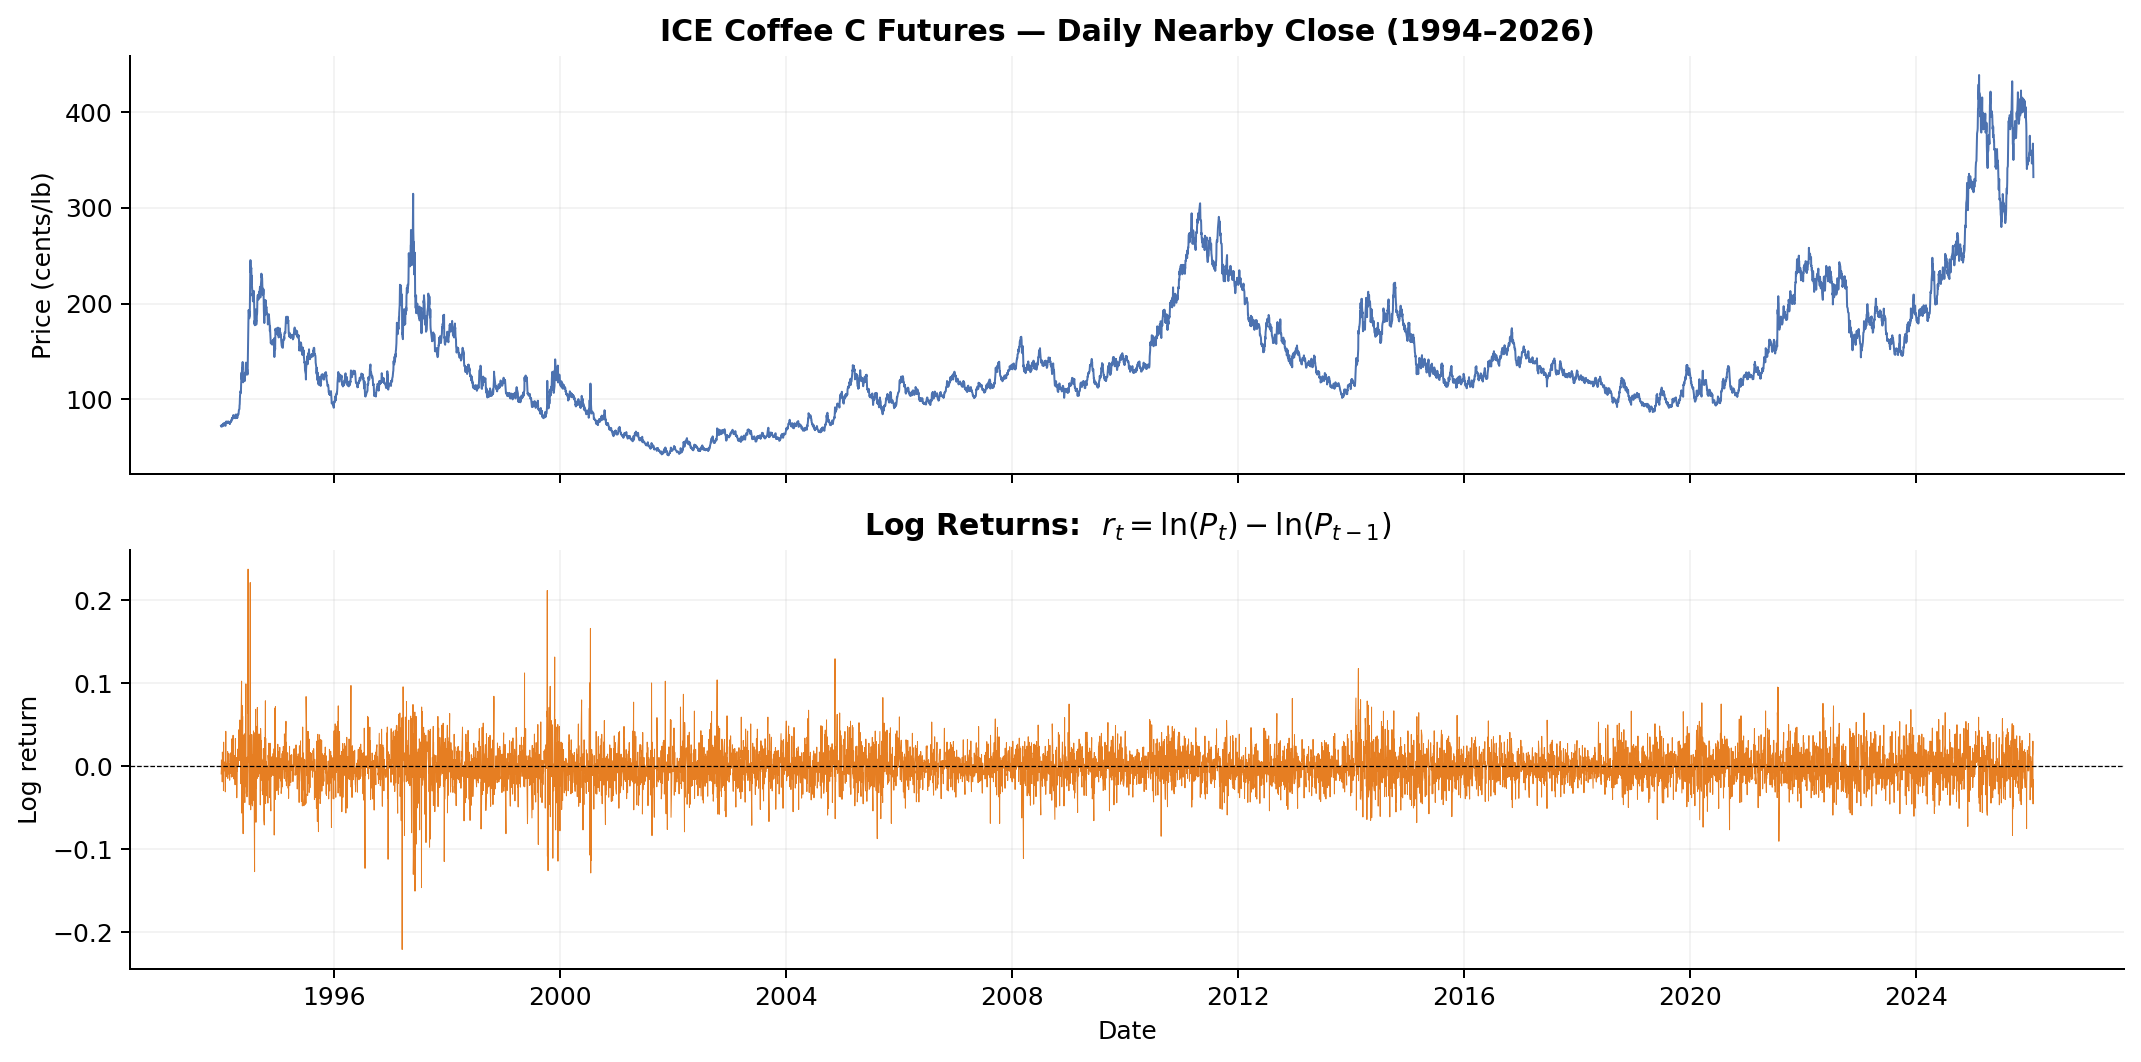

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True, dpi=180)

axes[0].plot(df["ds"], prices, linewidth=0.8, color="#4C72B0")
axes[0].set_title(
    "ICE Coffee C Futures — Daily Nearby Close (1994–2026)",
    fontsize=12,
    weight="semibold",
)
axes[0].set_ylabel("Price (cents/lb)")
axes[0].grid(alpha=0.15)
axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)

axes[1].plot(df["ds"].iloc[1:], log_returns, linewidth=0.4, color="#E67E22")
axes[1].axhline(0, color="black", lw=0.5, ls="--")
axes[1].set_title(
    r"Log Returns:  $r_t = \ln(P_t) - \ln(P_{t-1})$", fontsize=12, weight="semibold"
)
axes[1].set_ylabel("Log return")
axes[1].set_xlabel("Date")
axes[1].grid(alpha=0.15)
axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)

fig.tight_layout()
fig.savefig(FIG_DIR / "prices_vs_logreturns.png", dpi=300, bbox_inches="tight")
plt.show()

The ADF result is exactly what you'd expect of a commodity price:
prices are non-stationary (they wander), log-returns are stationary
(they hover around zero with roughly constant variance &mdash; the
well-known volatility clustering notwithstanding).

## 3. Return autocorrelation: Ljung-Box test

Under weak-form market efficiency, daily returns should not be
linearly predictable from their own past. The Ljung-Box test checks
the joint null that all autocorrelations up to lag $L$ are zero,
with statistic $Q(L) = T(T+2) \sum_{k=1}^{L} \hat\rho_k^2 / (T-k)$
asymptotically $\chi^2_L$ under $H_0$. We test on log-returns at
$L = 10$ (about two trading weeks) and $L = 20$ (a trading month).

In [6]:
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.stattools import acf

lb = acorr_ljungbox(log_returns, lags=[10, 20], return_df=True)
print("Ljung-Box on log-returns:")
print(
    f"  L = 10:  Q = {lb.iloc[0]['lb_stat']:>7.2f},  p = {lb.iloc[0]['lb_pvalue']:.4f}"
)
print(
    f"  L = 20:  Q = {lb.iloc[1]['lb_stat']:>7.2f},  p = {lb.iloc[1]['lb_pvalue']:.4f}"
)

# Magnitude of the autocorrelations underneath the rejection.
rho = acf(log_returns, nlags=20, fft=False)[1:]  # drop lag 0
mean_abs_rho = float(np.mean(np.abs(rho)))
max_abs_rho = float(np.max(np.abs(rho)))
print(f"\n|\u03c1(k)| averaged over lags 1\u201320:  {mean_abs_rho:.4f}")
print(f"|\u03c1(k)| max over lags 1\u201320:       {max_abs_rho:.4f}")

Ljung-Box on log-returns:
  L = 10:  Q =   24.53,  p = 0.0063
  L = 20:  Q =   39.31,  p = 0.0061

|ρ(k)| averaged over lags 1–20:  0.0129
|ρ(k)| max over lags 1–20:       0.0396


Ljung-Box formally rejects the joint zero-autocorrelation null at
both lag windows ($p \approx 0.006$). The rejection is real but
needs context: with $T = 8{,}103$ observations, even tiny
autocorrelations are detectable, and the average
$|\hat\rho(k)|$ over lags 1\u201320 is on the order of $10^{-2}$.
This is the textbook stylized fact for liquid financial returns
(Cont 2001): linear return autocorrelations are *statistically*
non-zero at large sample sizes but *economically negligible*,
too small to exploit through trading rules or point-forecast
models. The heteroskedasticity-robust variance-ratio test in &sect;4
confirms the practical reading &mdash; random-walk dynamics are
not rejected at any horizon &mdash; because the heteroskedasticity
VR is robust to (and LB is not) explains most of the detectable
serial structure.

The companion ACF visualization &mdash; returns vs. squared returns
side-by-side &mdash; appears in &sect;4 of notebook 04, where the
contrast (returns nearly flat, squared returns persistent) is what
motivates the GARCH model.

## 4. Lo-MacKinlay Variance Ratio Test

Under the random-walk null, the variance of $q$-period returns equals $q$
times the variance of one-period returns, so $\mathrm{VR}(q) = \mathrm{Var}(r_t^{(q)}) / [q \cdot \mathrm{Var}(r_t)]$ should equal 1 at every horizon. Deviations are direct
evidence against the random-walk hypothesis. We use the heteroskedasticity-
robust $z$-statistic of Lo and MacKinlay (1988), which handles the
volatility clustering coffee returns exhibit.

Unlike ADF (which tests for a unit root in levels) or Hurst (which tests
for long memory), the variance-ratio test is a direct test of the
random-walk hypothesis and is the canonical test in the forecasting
literature going back to Meese-Rogoff.

In [7]:
from scipy import stats as _stats


def variance_ratio_test(x, q):
    """Lo-MacKinlay variance ratio with heteroskedasticity-robust z-stat."""
    x = np.asarray(x, dtype=float)
    T = len(x)
    mu = x.mean()
    var1 = np.sum((x - mu) ** 2) / (T - 1)
    xq = np.convolve(x, np.ones(q), mode="valid")
    m = (T - q + 1) * (1 - q / T)
    varq = np.sum((xq - q * mu) ** 2) / m
    VR = varq / (q * var1)
    deltas = []
    for j in range(1, q):
        num = np.sum(((x[j:] - mu) ** 2) * ((x[:-j] - mu) ** 2))
        den = (np.sum((x - mu) ** 2)) ** 2 / T
        deltas.append(num / den)
    theta = sum(((2 * (q - j) / q) ** 2) * d for j, d in enumerate(deltas, start=1))
    z = (VR - 1) / np.sqrt(theta / T)
    p = 2 * (1 - _stats.norm.cdf(abs(z)))
    return VR, z, p


print(f"  {'q':>4} | {'VR(q)':>7} | {'z (het-robust)':>15} | {'p-value':>8}")
print(f"  {'-' * 4}-+-{'-' * 7}-+-{'-' * 15}-+-{'-' * 8}")
for q in [2, 4, 8, 16, 32]:
    VR, z, p = variance_ratio_test(log_returns, q)
    print(f"  {q:>4} | {VR:>7.4f} | {z:>15.3f} | {p:>8.4f}")

     q |   VR(q) |  z (het-robust) |  p-value
  -----+---------+-----------------+---------
     2 |  0.9863 |          -0.837 |   0.4028
     4 |  0.9786 |          -0.707 |   0.4793
     8 |  0.9472 |          -1.136 |   0.2560
    16 |  0.9409 |          -0.884 |   0.3766
    32 |  0.8517 |          -1.604 |   0.1088


> VR(q) is within rounding distance of 1 at every horizon and no
> z-statistic reaches conventional significance. We fail to reject the
> random-walk null at q = 2, 4, 8, 16, and 32 days. This is the
> strongest direct evidence in the a priori battery that the series is
> consistent with a random walk.

## 5. Synthesis

In [8]:
import pandas as pd

summary = pd.DataFrame(
    [
        {
            "Metric": "ADF (Augmented Dickey-Fuller)",
            "Representation": "prices / log-returns",
            "Value": f"ADF = {adf_price[0]:+.2f} (p = {adf_price[1]:.3f}) / ADF = {adf_ret[0]:+.2f} (p < 0.001)",
            "Interpretation": "Prices non-stationary; log-returns stationary",
        },
        {
            "Metric": "KPSS",
            "Representation": "prices / log-returns",
            "Value": f"stat = {kpss_price_stat:+.2f} / stat = {kpss_ret_stat:+.2f}",
            "Interpretation": "Reverses ADF null and agrees: rejects stationarity on prices, fails to reject on returns",
        },
        {
            "Metric": "Phillips-Perron",
            "Representation": "prices / log-returns",
            "Value": f"stat = {pp_price.stat:+.2f} (p = {pp_price.pvalue:.3f}) / stat = {pp_ret.stat:+.2f} (p < 0.001)",
            "Interpretation": "Heteroskedasticity-robust confirmation of ADF",
        },
        {
            "Metric": "Ljung-Box on returns",
            "Representation": "log-returns",
            "Value": f"Q(20) = {lb.iloc[1]['lb_stat']:.1f}, p = {lb.iloc[1]['lb_pvalue']:.4f}",
            "Interpretation": (
                f"Reject H0 of zero autocorrelation; mean |\u03c1(k)| \u2248 {mean_abs_rho:.3f} \u2014 "
                "statistically detectable but economically negligible (Cont 2001)"
            ),
        },
        {
            "Metric": "Variance Ratio (Lo-MacKinlay)",
            "Representation": "log-returns",
            "Value": "VR(q) \u2248 1 at q=2,4,8,16,32",
            "Interpretation": "Direct test of random walk: fails to reject at all horizons",
        },
    ]
)
summary

,Metric,Representation,Value,Interpretation
0,ADF (Augmented Dickey-Fuller),prices / log-returns,ADF = -1.45 (p = 0.557) / ADF = -20.88 (p < 0....,Prices non-stationary; log-returns stationary
1,KPSS,prices / log-returns,stat = +3.96 / stat = +0.05,Reverses ADF null and agrees: rejects stationa...
2,Phillips-Perron,prices / log-returns,stat = -1.73 (p = 0.418) / stat = -91.70 (p < ...,Heteroskedasticity-robust confirmation of ADF
3,Ljung-Box on returns,log-returns,"Q(20) = 39.3, p = 0.0061",Reject H0 of zero autocorrelation; mean |ρ(k)|...
4,Variance Ratio (Lo-MacKinlay),log-returns,"VR(q) ≈ 1 at q=2,4,8,16,32",Direct test of random walk: fails to reject at...


**Conclusion.** Coffee futures exhibit the statistical fingerprint of a
near-random walk. ADF, KPSS, and Phillips-Perron agree that prices are
non-stationary and log-returns are stationary &mdash; the standard
I(1) signature for a liquid commodity series. Ljung-Box formally
rejects the joint zero-autocorrelation null at $T = 8{,}103$, but the
average $|\hat\rho(k)|$ over lags 1\u201320 is on the order of $10^{-2}$,
consistent with the textbook stylized fact for liquid returns (Cont
2001): statistically detectable but economically negligible. The
Lo-MacKinlay variance-ratio test, which uses a heteroskedasticity-
robust z-statistic, fails to reject the random-walk null at every
tested horizon ($q = 2$ to 32). This is the empirical signature of
**weak-form market efficiency** (Fama 1970): past prices alone do not
contain exploitable information about future price movements. The a
priori prior is therefore strong: simple baselines that match this
structure (random walk with drift, na\u00efve, exponential smoothing)
should be competitive with arbitrarily complex models. Notebook 01
tested that prior in practice, and notebook 02's statistical tests are
consistent with it: simple baselines cluster with the more complex
models, and nine of ten models are jointly indistinguishable in the
Model Confidence Set.

---

**On log-returns.** They appear here only where analytically required
(stationarity testing, the Ljung-Box and variance-ratio tests). They
will reappear in notebook 04 (GARCH deployment), where modeling their
volatility structure directly is what produces the prediction intervals.

**Companion notebook:** [`03b_exploratory_dynamics.ipynb`](03b_exploratory_dynamics.ipynb)
&mdash; Hurst + Lo's R/S, spectral predictability, permutation entropy,
and Rosenstein Lyapunov with a surrogate-data null. Independent
confirmations of the random-walk verdict above.

**Next notebook:** [`04_deployment_garch.ipynb`](04_deployment_garch.ipynb)
&mdash; operationalizes the log-return + volatility findings above as
a GARCH(1,1)-t model with Student-t innovations and zero mean,
producing the 63-day forecast with 80% and 95% prediction intervals
used in the live deployment.